## 1. Kütüphaneler

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models as torch_models

print('TensorFlow:', tf.__version__)
print('PyTorch:', torch.__version__)
print('GPU (TF):', len(tf.config.list_physical_devices('GPU')) > 0)
print('GPU (PyTorch):', torch.cuda.is_available())

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH  = '/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 '
IMG_SIZE   = 64
IMG_SIZE_TL= 64
BATCH_SIZE = 32
EPOCHS     = 10
NUM_CLASSES= 4
CLASSES    = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
SEED       = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

2026-02-28 14:01:00.228569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772287260.440428      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772287260.501972      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772287261.024708      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772287261.024764      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772287261.024767      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
PyTorch: 2.9.0+cu126
GPU (TF): True
GPU (PyTorch): True


## 2. EDA

        train  val  test
CNV     37205    8   242
DME     11348    8   242
DRUSEN   8616    8   242
NORMAL  26315    8   242

Toplam: 84484 görüntü


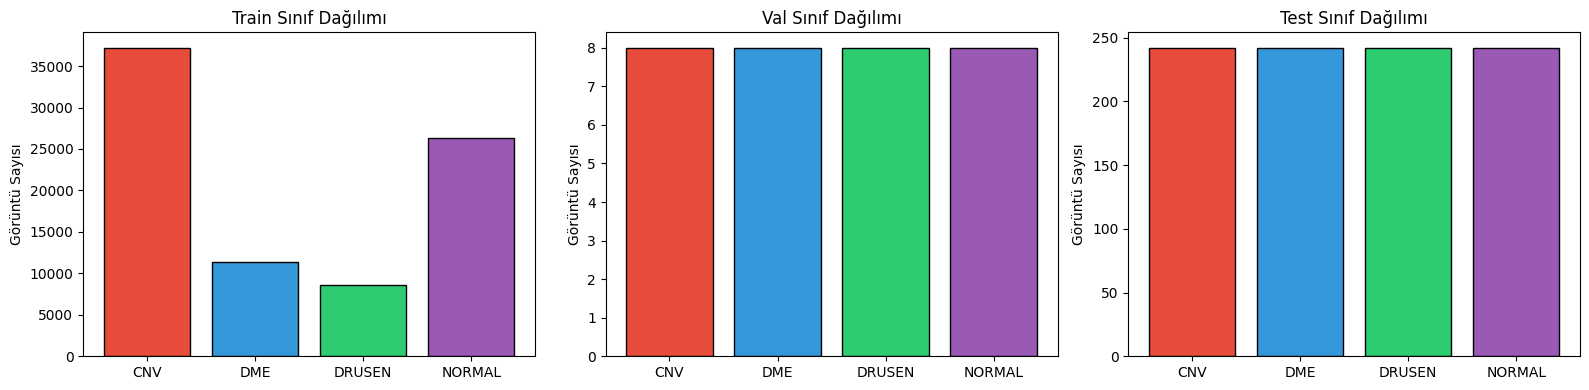

In [2]:
# Sınıf dağılımı
split_counts = {}
for split in ['train', 'val', 'test']:
    split_counts[split] = {}
    for cls in CLASSES:
        cls_path = os.path.join(BASE_PATH, split, cls)
        if os.path.exists(cls_path):
            split_counts[split][cls] = len(os.listdir(cls_path))

df_counts = pd.DataFrame(split_counts).fillna(0).astype(int)
print(df_counts)
print(f'\nToplam: {df_counts.values.sum()} görüntü')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, split in enumerate(['train', 'val', 'test']):
    vals = [split_counts[split].get(cls, 0) for cls in CLASSES]
    axes[i].bar(CLASSES, vals, color=colors, edgecolor='black')
    axes[i].set_title(f'{split.capitalize()} Sınıf Dağılımı', fontsize=12)
    axes[i].set_ylabel('Görüntü Sayısı')

plt.tight_layout()
plt.show()

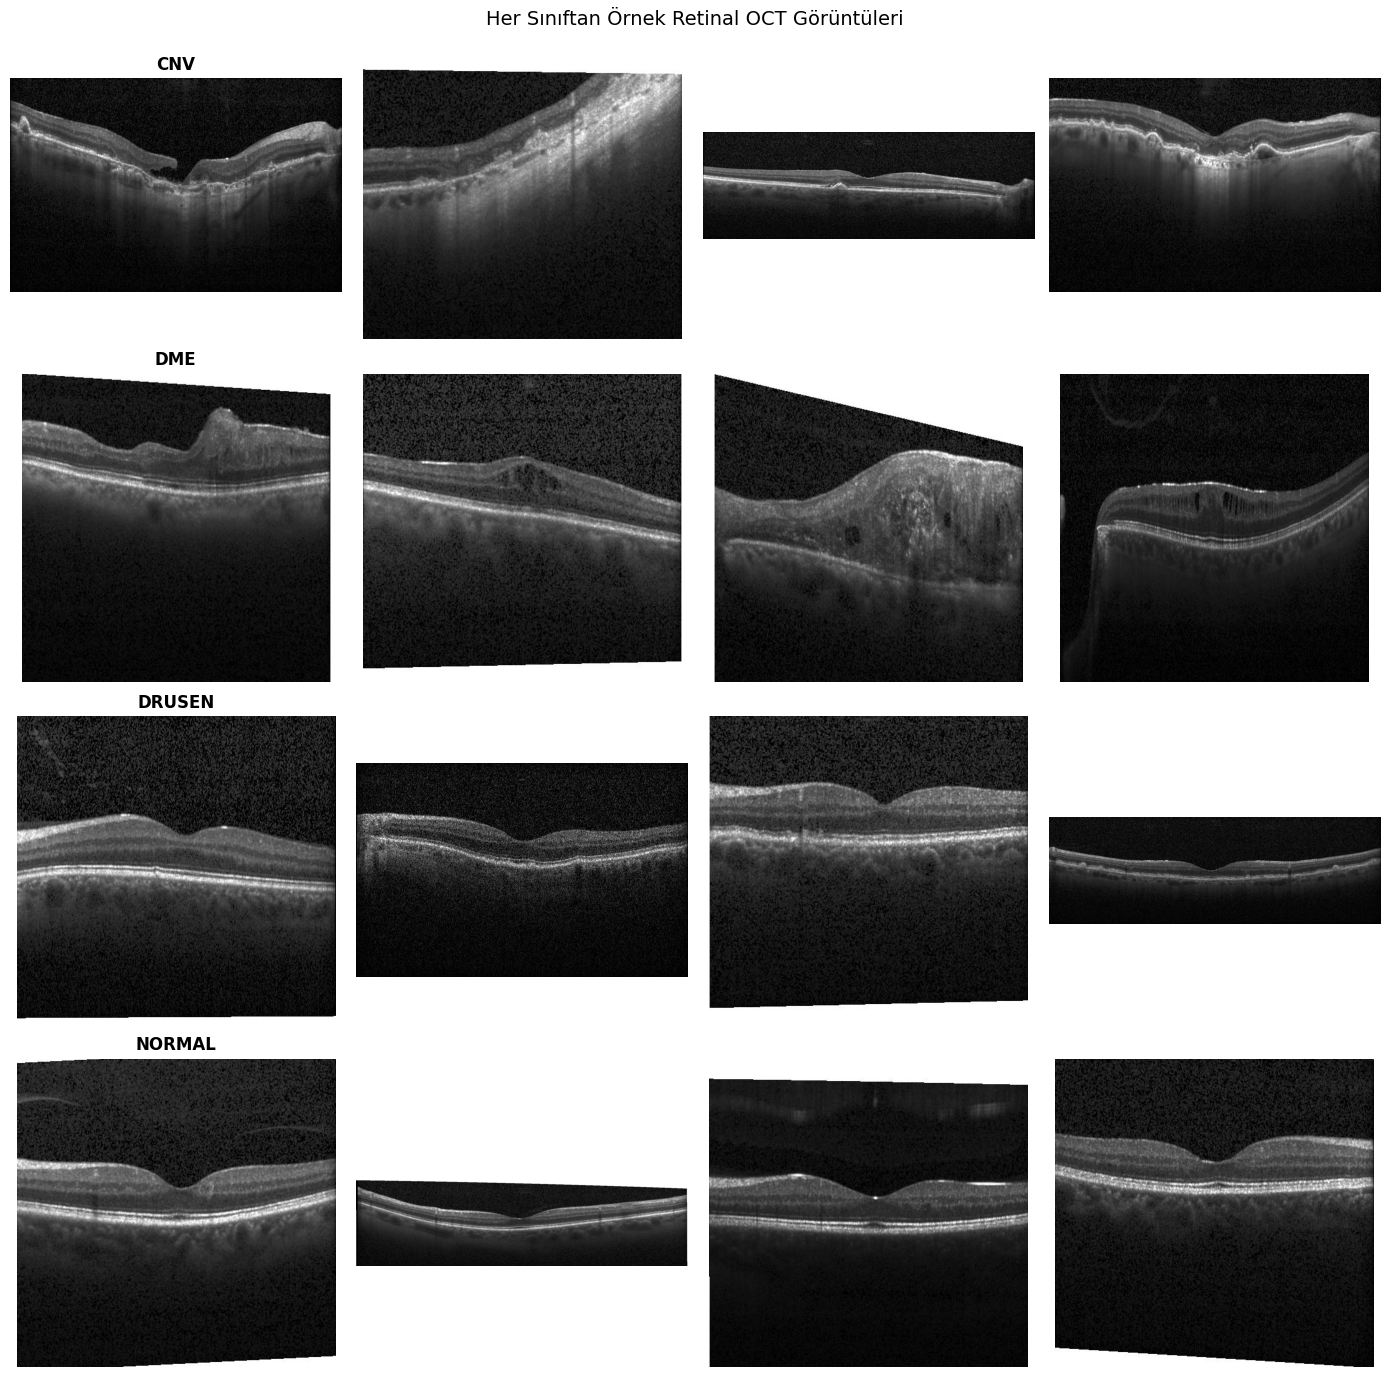

In [3]:
# Her sınıftan örnek görüntüler
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(BASE_PATH, 'train', cls)
    samples = np.random.choice(os.listdir(cls_path), 4, replace=False)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls if col == 0 else '', fontsize=12, fontweight='bold')
        axes[row][col].axis('off')

plt.suptitle('Her Sınıftan Örnek Retinal OCT Görüntüleri', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing & Data Generators

In [4]:
# ---- TensorFlow ImageDataGenerators ----
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest',
    validation_split=0.2
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_tf_generators(img_size):
    train_gen = train_datagen.flow_from_directory(
        os.path.join(BASE_PATH, 'train'),
        target_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASSES,
        subset='training',
        shuffle=True,
        seed=SEED
    )
    val_gen = train_datagen.flow_from_directory(
        os.path.join(BASE_PATH, 'train'),
        target_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASSES,
        subset='validation',
        shuffle=False,
        seed=SEED
    )
    test_gen = val_test_datagen.flow_from_directory(
        os.path.join(BASE_PATH, 'test'),
        target_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASSES,
        shuffle=False
    )
    return train_gen, val_gen, test_gen

train_gen_64, val_gen_64, test_gen_64 = make_tf_generators(IMG_SIZE)
print(f'TF Train: {train_gen_64.samples} | Val: {val_gen_64.samples} | Test: {test_gen_64.samples}')

class_counts = [split_counts['train'].get(cls, 1) for cls in CLASSES]
total = sum(class_counts)
class_weight_dict = {i: total / (NUM_CLASSES * cnt) for i, cnt in enumerate(class_counts)}
print('Class Weights:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls}: {class_weight_dict[i]:.2f}')


Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.
Found 968 images belonging to 4 classes.
TF Train: 66788 | Val: 16696 | Test: 968
Class Weights:
  CNV: 0.56
  DME: 1.84
  DRUSEN: 2.42
  NORMAL: 0.79


In [5]:
from sklearn.model_selection import train_test_split

class OCTDataset(Dataset):
    def __init__(self, samples, img_size, transform=None):
        self.samples = samples
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB').resize((self.img_size, self.img_size))
        img = torch.tensor(np.array(img), dtype=torch.float32).permute(2, 0, 1) / 255.0
        if self.transform:
            img = self.transform(img)
        return img, label

def collect_samples(split):
    samples = []
    for label_idx, cls in enumerate(CLASSES):
        cls_path = os.path.join(BASE_PATH, split, cls)
        if not os.path.exists(cls_path): continue
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                samples.append((os.path.join(cls_path, fname), label_idx))
    return samples

# Train'den %10 val, %10 test ayır + orijinal test setini ekle
all_train_samples = collect_samples('train')
original_test_samples = collect_samples('test')

labels_for_split = [s[1] for s in all_train_samples]
train_samples, temp_samples = train_test_split(
    all_train_samples, test_size=0.2, random_state=SEED, stratify=labels_for_split
)
temp_labels = [s[1] for s in temp_samples]
val_samples, extra_test_samples = train_test_split(
    temp_samples, test_size=0.5, random_state=SEED, stratify=temp_labels
)
test_samples = extra_test_samples + original_test_samples

print(f'PyTorch Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])
tl_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def make_pt_loaders(img_size, normalize=False):
    tr = transforms.Compose([aug_transform, tl_normalize]) if normalize else aug_transform
    vt = tl_normalize if normalize else None
    return (
        DataLoader(OCTDataset(train_samples, img_size, transform=tr), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2),
        DataLoader(OCTDataset(val_samples,   img_size, transform=vt), batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
        DataLoader(OCTDataset(test_samples,  img_size, transform=vt), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    )

train_loader_64, val_loader_64, test_loader_64 = make_pt_loaders(IMG_SIZE)

class_weights_tensor = torch.tensor(
    [class_weight_dict[i] for i in range(NUM_CLASSES)], dtype=torch.float32
).to(DEVICE)

print('PyTorch loaders hazır.')


PyTorch Train: 66787 | Val: 8348 | Test: 9317
PyTorch loaders hazır.


## 4. Yardımcı Fonksiyonlar

In [6]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} - Accuracy'); axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} - Loss'); axes[1].legend()
    plt.tight_layout(); plt.show()

def eval_tf(model, test_gen, title):
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true = test_gen.classes
    print(f'{title} Test Accuracy: {accuracy_score(y_true, y_pred):.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES))
    return y_true, y_pred

def train_torch(model, train_loader, val_loader, epochs=EPOCHS,
                class_weights=None, save_path='best_model.pth'):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    best_val_acc, patience_counter = 0, 0

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward(); optimizer.step()
            train_loss += loss.item()
            correct += (out.argmax(1) == y_batch).sum().item()
            total += len(y_batch)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                out = model(X_batch)
                val_loss += criterion(out, y_batch).item()
                val_correct += (out.argmax(1) == y_batch).sum().item()
                val_total += len(y_batch)

        t_acc = correct / total
        v_acc = val_correct / val_total
        t_loss = train_loss / len(train_loader)
        v_loss = val_loss / len(val_loader)
        history['train_acc'].append(t_acc); history['val_acc'].append(v_acc)
        history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
        scheduler.step(v_loss)
        print(f'Epoch {epoch+1}/{epochs} - Loss: {t_loss:.4f} - Acc: {t_acc:.4f} - Val Loss: {v_loss:.4f} - Val Acc: {v_acc:.4f}')

        if v_acc > best_val_acc:
            best_val_acc = v_acc; patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print('Early stopping!'); break
    return history

def eval_torch(model, test_loader, save_path, title):
    model.load_state_dict(torch.load(save_path))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            out = model(X_batch.to(DEVICE))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.numpy())
    print(f'{title} Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}')
    print(classification_report(all_labels, all_preds, target_names=CLASSES))
    return all_labels, all_preds

def plot_torch_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_acc'], label='Train')
    axes[0].plot(history['val_acc'], label='Val')
    axes[0].set_title(f'{title} - Accuracy'); axes[0].legend()
    axes[1].plot(history['train_loss'], label='Train')
    axes[1].plot(history['val_loss'], label='Val')
    axes[1].set_title(f'{title} - Loss'); axes[1].legend()
    plt.tight_layout(); plt.show()

print('Yardımcı fonksiyonlar hazır.')

Yardımcı fonksiyonlar hazır.


## 5. CNN - TensorFlow/Keras

I0000 00:00:1772287352.207844      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13755 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772287352.213919      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,580 (8.36 MB)

 Trainable params: 2,192,132 (8.36 MB)

...

Epoch 1/10


I0000 00:00:1772287357.045805      91 service.cc:152] XLA service 0x7ecd5c005440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772287357.045846      91 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772287357.045850      91 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772287357.656501      91 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/2088 ━━━━━━━━━━━━━━━━━━━━ 5:33:51 10s/step - accuracy: 0.3438 - loss: 3.5571

I0000 00:00:1772287363.836893      91 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2088/2088 ━━━━━━━━━━━━━━━━━━━━ 840s 398ms/step - accuracy: 0.4188 - loss: 1.5223 - val_accuracy: 0.6180 - val_loss: 0.9488 - learning_rate: 0.0010
Epoch 2/10
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 405s 194ms/step - accuracy: 0.5857 - loss: 1.0481 - val_accuracy: 0.6532 - val_loss: 0.7804 - learning_rate: 0.0010
Epoch 3/10
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 392s 188ms/step - accuracy: 0.6464 - loss: 0.8987 - val_accuracy: 0.8022 - val_loss: 0.5588 - learning_rate: 0.0010
Epoch 4/10
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 395s 189ms/step - accuracy: 0.6880 - loss: 0.8212 - val_accuracy: 0.7984 - val_loss: 0.5565 - learning_rate: 0.0010
Epoch 5/10
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 390s 187ms/step - accuracy: 0.7123 - loss: 0.7568 - val_accuracy: 0.7378 - val_loss: 0.6072 - learning_rate: 0.0010
Epoch 6/10
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 408s 195ms/step - accuracy: 0.7338 - loss: 0.7263 - val_accuracy: 0.7404 - val_loss: 0.7257 - learning_rate: 0.0010
Epoch 7/10
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 397s 190ms/step - acc

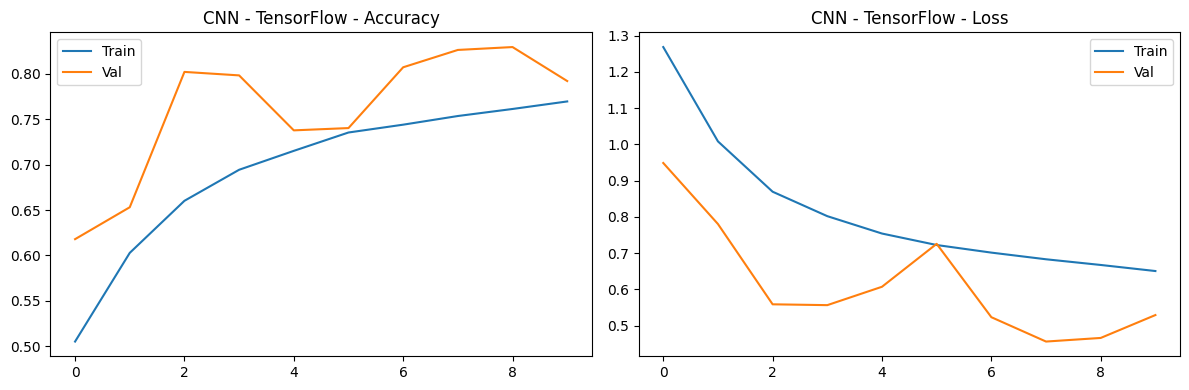

CNN TF Test Accuracy: 0.8616
              precision    recall  f1-score   support

         CNV       0.84      0.93      0.88       242
         DME       0.97      0.70      0.82       242
      DRUSEN       0.89      0.81      0.85       242
      NORMAL       0.80      1.00      0.89       242

    accuracy                           0.86       968
   macro avg       0.87      0.86      0.86       968
weighted avg       0.87      0.86      0.86       968



In [7]:
def build_cnn_tf():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(256, activation='relu'), layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(optimizer=optimizers.Adam(0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_tf = build_cnn_tf()
cnn_tf.summary()

history_cnn_tf = cnn_tf.fit(
    train_gen_64,
    validation_data=val_gen_64,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)
plot_history(history_cnn_tf, 'CNN - TensorFlow')
y_true_cnn_tf, y_pred_cnn_tf = eval_tf(cnn_tf, test_gen_64, 'CNN TF')

## 6. CNN - PyTorch

Epoch 1/10 - Loss: 1.2721 - Acc: 0.5142 - Val Loss: 1.0720 - Val Acc: 0.7177
Epoch 2/10 - Loss: 1.1291 - Acc: 0.6391 - Val Loss: 0.9309 - Val Acc: 0.7512
Epoch 3/10 - Loss: 1.0262 - Acc: 0.6691 - Val Loss: 0.7282 - Val Acc: 0.8161
Epoch 4/10 - Loss: 0.8928 - Acc: 0.7033 - Val Loss: 0.5952 - Val Acc: 0.8383
Epoch 5/10 - Loss: 0.7608 - Acc: 0.7435 - Val Loss: 0.4988 - Val Acc: 0.8509
Epoch 6/10 - Loss: 0.6567 - Acc: 0.7854 - Val Loss: 0.4933 - Val Acc: 0.8294
Epoch 7/10 - Loss: 0.5996 - Acc: 0.8109 - Val Loss: 0.4021 - Val Acc: 0.8758
Epoch 8/10 - Loss: 0.5552 - Acc: 0.8287 - Val Loss: 0.4051 - Val Acc: 0.8630
Epoch 9/10 - Loss: 0.5276 - Acc: 0.8362 - Val Loss: 0.3840 - Val Acc: 0.8815
Epoch 10/10 - Loss: 0.5081 - Acc: 0.8429 - Val Loss: 0.3642 - Val Acc: 0.8844


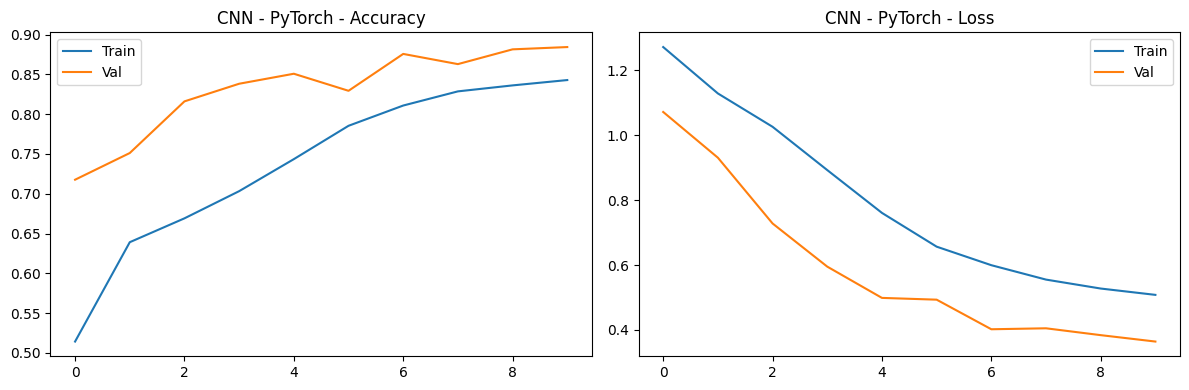

CNN PyTorch Test Accuracy: 0.8976
              precision    recall  f1-score   support

         CNV       0.98      0.89      0.93      3963
         DME       0.83      0.92      0.87      1377
      DRUSEN       0.74      0.76      0.75      1103
      NORMAL       0.89      0.95      0.92      2874

    accuracy                           0.90      9317
   macro avg       0.86      0.88      0.87      9317
weighted avg       0.90      0.90      0.90      9317



In [8]:
class CNN_PyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x): return self.classifier(self.features(x))

cnn_torch = CNN_PyTorch().to(DEVICE)
history_cnn_torch = train_torch(cnn_torch, train_loader_64, val_loader_64,
                                 class_weights=class_weights_tensor,
                                 save_path='best_cnn_torch.pth')
plot_torch_history(history_cnn_torch, 'CNN - PyTorch')
y_true_cnn_torch, y_pred_cnn_torch = eval_torch(cnn_torch, test_loader_64,
                                                  'best_cnn_torch.pth', 'CNN PyTorch')

## 7. Transfer Learning - Veri Hazırlığı (64x64)

In [9]:
train_gen_128, val_gen_128, test_gen_128 = make_tf_generators(IMG_SIZE_TL)
train_loader_128, val_loader_128, test_loader_128 = make_pt_loaders(IMG_SIZE_TL, normalize=True)
steps_tl = len(train_gen_128)
print(f'TF Generator - Train steps: {steps_tl}')
print('Transfer Learning verileri hazir.')


Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.
Found 968 images belonging to 4 classes.
TF Generator - Train steps: 2088
Transfer Learning verileri hazir.


## 8. Transfer Learning - EfficientNetB0 (TensorFlow)

Found 75138 images belonging to 4 classes.
Found 8346 images belonging to 4 classes.
Found 968 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Aşama 1: Frozen (8 epoch)...
Epoch 1/8


2026-02-28 16:05:33.054019: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:05:33.186527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:05:33.495524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:05:33.635023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:05:34.373096: E external/local_xla/xla/stream_

1747/2349 ━━━━━━━━━━━━━━━━━━━━ 1:27 145ms/step - accuracy: 0.5194 - loss: 1.3583

2026-02-28 16:10:01.380518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:10:01.512396: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:10:01.812532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:10:01.953134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 16:10:02.663706: E external/local_xla/xla/stream_

2349/2349 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5297 - loss: 1.3045

...

2349/2349 ━━━━━━━━━━━━━━━━━━━━ 454s 182ms/step - accuracy: 0.5297 - loss: 1.3044 - val_accuracy: 0.6355 - val_loss: 0.8485 - learning_rate: 0.0010
Epoch 2/8
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 414s 176ms/step - accuracy: 0.5940 - loss: 1.0309 - val_accuracy: 0.6403 - val_loss: 0.8663 - learning_rate: 0.0010
Epoch 3/8
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 419s 178ms/step - accuracy: 0.6064 - loss: 1.0079 - val_accuracy: 0.6885 - val_loss: 0.7811 - learning_rate: 0.0010
Epoch 4/8
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 428s 182ms/step - accuracy: 0.6119 - loss: 1.0010 - val_accuracy: 0.6571 - val_loss: 0.8004 - learning_rate: 0.0010
Epoch 5/8
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 438s 186ms/step - accuracy: 0.6124 - loss: 0.9953 - val_accuracy: 0.6736 - val_loss: 0.7894 - learning_rate: 0.0010
Epoch 6/8
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6136 - loss: 0.9954
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 411s 175ms/step - accuracy: 0

2026-02-28 17:02:05.479325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:02:05.618814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:02:05.754852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:02:05.934647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:02:06.089131: E external/local_xla/xla/stream_

 190/2349 ━━━━━━━━━━━━━━━━━━━━ 4:50 135ms/step - accuracy: 0.4819 - loss: 1.2135

2026-02-28 17:02:43.976601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:02:44.119472: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:02:44.253567: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2349/2349 ━━━━━━━━━━━━━━━━━━━━ 450s 181ms/step - accuracy: 0.5233 - loss: 1.1606 - val_accuracy: 0.6335 - val_loss: 0.8975 - learning_rate: 1.0000e-05
Epoch 2/7
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 399s 170ms/step - accuracy: 0.5945 - loss: 1.0501 - val_accuracy: 0.6579 - val_loss: 0.8446 - learning_rate: 1.0000e-05
Epoch 3/7
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 444s 189ms/step - accuracy: 0.6171 - loss: 1.0039 - val_accuracy: 0.6711 - val_loss: 0.8165 - learning_rate: 1.0000e-05
Epoch 4/7
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 473s 201ms/step - accuracy: 0.6224 - loss: 0.9883 - val_accuracy: 0.6692 - val_loss: 0.8022 - learning_rate: 1.0000e-05
Epoch 5/7
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 481s 205ms/step - accuracy: 0.6365 - loss: 0.9622 - val_accuracy: 0.6758 - val_loss: 0.7819 - learning_rate: 1.0000e-05
Epoch 6/7
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 427s 182ms/step - accuracy: 0.6344 - loss: 0.9583 - val_accuracy: 0.6898 - val_loss: 0.7710 - learning_rate: 1.0000e-05
Epoch 7/7
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 432

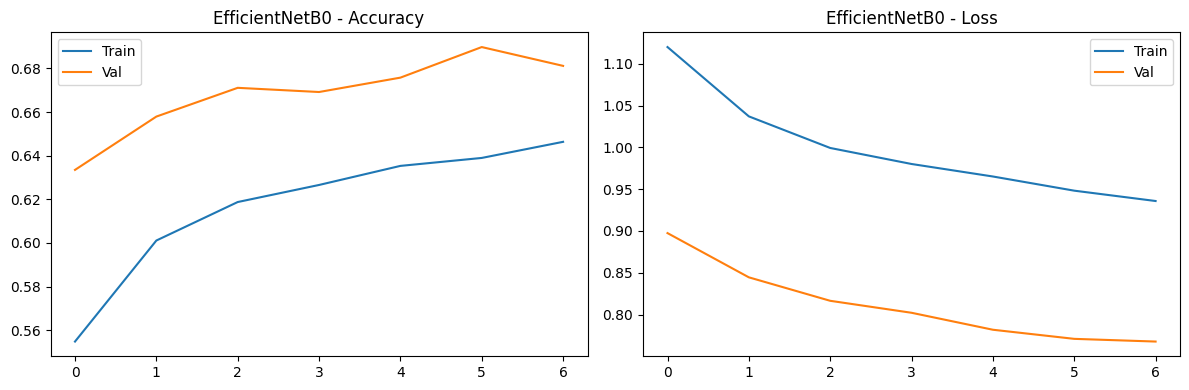

2026-02-28 17:53:51.347195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:53:51.479048: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:53:51.611509: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:53:51.904820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:53:52.043947: E external/local_xla/xla/stream_

EfficientNetB0 Test Accuracy: 0.7593
              precision    recall  f1-score   support

         CNV       0.79      0.94      0.86       242
         DME       0.94      0.68      0.79       242
      DRUSEN       0.60      0.81      0.69       242
      NORMAL       0.83      0.61      0.70       242

    accuracy                           0.76       968
   macro avg       0.79      0.76      0.76       968
weighted avg       0.79      0.76      0.76       968



In [10]:
# EfficientNetB0 için ayrı generator - rescale YOK (model kendi normalize ediyor)
eff_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest',
    validation_split=0.1
)
eff_test_datagen = ImageDataGenerator()  # rescale yok!

eff_train_gen = eff_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'train'),
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    subset='training',
    shuffle=True,
    seed=SEED
)
eff_val_gen = eff_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'train'),
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    subset='validation',
    shuffle=False,
    seed=SEED
)
eff_test_gen = eff_test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'test'),
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

base_eff = EfficientNetB0(weights='imagenet', include_top=False,
                           input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
base_eff.trainable = False

eff_model = models.Sequential([
    base_eff,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'), layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
eff_model.compile(optimizer=optimizers.Adam(0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])

print('Aşama 1: Frozen (8 epoch)...')
eff_model.fit(eff_train_gen, validation_data=eff_val_gen,
              epochs=8, class_weight=class_weight_dict, callbacks=callbacks)

print('\nAşama 2: Fine-tuning (7 epoch)...')
base_eff.trainable = True
for layer in base_eff.layers[:-20]: layer.trainable = False
eff_model.compile(optimizer=optimizers.Adam(1e-5),
                   loss='categorical_crossentropy', metrics=['accuracy'])
history_eff = eff_model.fit(eff_train_gen, validation_data=eff_val_gen,
                             epochs=7, class_weight=class_weight_dict, callbacks=callbacks)

plot_history(history_eff, 'EfficientNetB0')
y_true_eff, y_pred_eff = eval_tf(eff_model, eff_test_gen, 'EfficientNetB0')


## 9. Transfer Learning - ResNet50 (PyTorch)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


Aşama 1: Frozen (8 epoch)...
Epoch 1/8 - Loss: 1.2743 - Acc: 0.4910 - Val Loss: 1.2874 - Val Acc: 0.5017
Epoch 2/8 - Loss: 1.2346 - Acc: 0.4966 - Val Loss: 1.2132 - Val Acc: 0.5331
Epoch 3/8 - Loss: 1.2203 - Acc: 0.5055 - Val Loss: 1.1642 - Val Acc: 0.5694
Epoch 4/8 - Loss: 1.2139 - Acc: 0.5014 - Val Loss: 1.1714 - Val Acc: 0.5544
Epoch 5/8 - Loss: 1.2040 - Acc: 0.5097 - Val Loss: 1.1474 - Val Acc: 0.5607
Epoch 6/8 - Loss: 1.1949 - Acc: 0.5112 - Val Loss: 1.1610 - Val Acc: 0.5049
Epoch 7/8 - Loss: 1.1970 - Acc: 0.5053 - Val Loss: 1.1414 - Val Acc: 0.5787
Epoch 8/8 - Loss: 1.1908 - Acc: 0.5134 - Val Loss: 1.1686 - Val Acc: 0.5180

Aşama 2: Fine-tuning (7 epoch)...
Epoch 1/7 - Loss: 0.8893 - Acc: 0.6793 - Val Loss: 0.7764 - Val Acc: 0.6869
Epoch 2/7 - Loss: 0.7730 - Acc: 0.7352 - Val Loss: 0.6287 - Val Acc: 0.7808
Epoch 3/7 - Loss: 0.7207 - Acc: 0.7665 - Val Loss: 0.6569 - Val Acc: 0.7929
Epoch 4/7 - Loss: 0.6919 - Acc: 0.7793 - Val Loss: 0.6084 - Val Acc: 0.8052
Epoch 5/7 - Loss: 0.6685

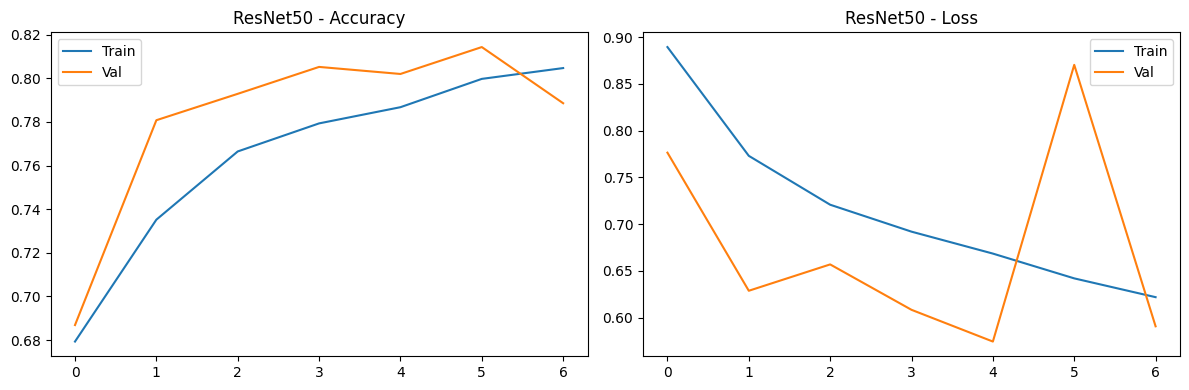

ResNet50 Test Accuracy: 0.8191
              precision    recall  f1-score   support

         CNV       0.88      0.91      0.90      3963
         DME       0.66      0.85      0.74      1377
      DRUSEN       0.64      0.60      0.62      1103
      NORMAL       0.91      0.76      0.82      2874

    accuracy                           0.82      9317
   macro avg       0.77      0.78      0.77      9317
weighted avg       0.83      0.82      0.82      9317



In [11]:
resnet = torch_models.resnet50(weights='IMAGENET1K_V1')
for param in resnet.parameters(): param.requires_grad = False
resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features, 256), nn.ReLU(),
    nn.Dropout(0.5), nn.Linear(256, NUM_CLASSES)
)
resnet = resnet.to(DEVICE)

print('Aşama 1: Frozen (8 epoch)...')
train_torch(resnet, train_loader_128, val_loader_128, epochs=8,
            class_weights=class_weights_tensor, save_path='best_resnet.pth')

print('\nAşama 2: Fine-tuning (7 epoch)...')
for param in resnet.layer4.parameters(): param.requires_grad = True
history_resnet = train_torch(resnet, train_loader_128, val_loader_128, epochs=7,
                              class_weights=class_weights_tensor, save_path='best_resnet.pth')

plot_torch_history(history_resnet, 'ResNet50')
y_true_resnet, y_pred_resnet = eval_torch(resnet, test_loader_128, 'best_resnet.pth', 'ResNet50')


## 12. Sonuçların Karşılaştırması

## 10. Transfer Learning - ResNet50 (TensorFlow)

Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.
Found 968 images belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Aşama 1: Frozen (8 epoch)...
Epoch 1/8
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 440s 205ms/step - accuracy: 0.5042 - loss: 1.4528 - val_accuracy: 0.5736 - val_loss: 0.9809 - learning_rate: 0.0010
Epoch 2/8
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 450s 216ms/step - accuracy: 0.5677 - loss: 1.0659 - val_accuracy: 0.6475 - val_loss: 0.8847 - learning_rate: 0.0010
Epoch 3/8
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 425s 204ms/step - accuracy: 0.5714 - loss: 1.0627 - val_accuracy: 0.6206 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 4/8
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 423s 203ms/step - accuracy: 0.5795 - loss: 1.0461 - val_accuracy: 0.6029 - val_loss: 0.9179 - learning_rate: 0.0010
Epoch 5/8
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5712 - loss: 1.0531
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


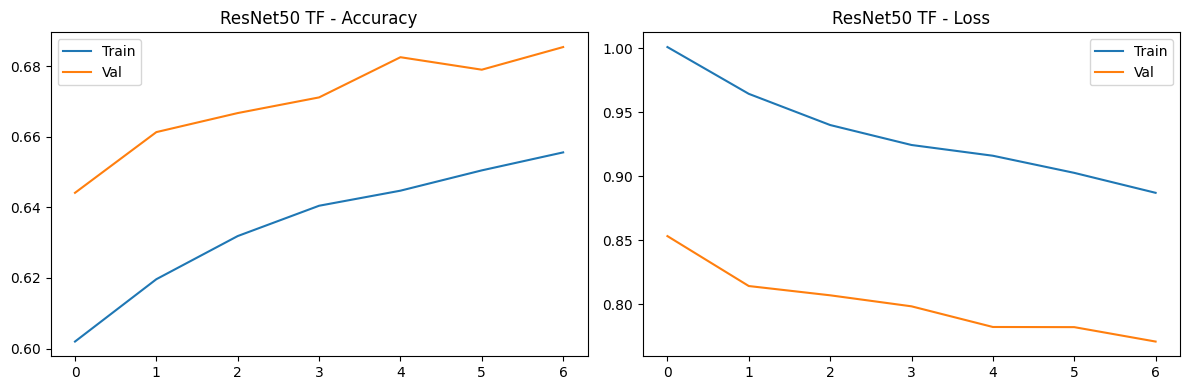

ResNet50 TF Test Accuracy: 0.7934
              precision    recall  f1-score   support

         CNV       0.94      0.88      0.91       242
         DME       0.88      0.69      0.78       242
      DRUSEN       0.64      0.87      0.74       242
      NORMAL       0.79      0.73      0.76       242

    accuracy                           0.79       968
   macro avg       0.81      0.79      0.80       968
weighted avg       0.81      0.79      0.80       968



In [12]:
from tensorflow.keras.applications import ResNet50

# ResNet50 için ayrı generator - rescale YOK
resnet_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest',
    validation_split=0.2
)
resnet_test_datagen = ImageDataGenerator()

resnet_train_gen = resnet_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'train'),
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    subset='training',
    shuffle=True,
    seed=SEED
)
resnet_val_gen = resnet_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'train'),
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    subset='validation',
    shuffle=False,
    seed=SEED
)
resnet_test_gen = resnet_test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'test'),
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

base_resnet_tf = ResNet50(weights='imagenet', include_top=False,
                           input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
base_resnet_tf.trainable = False

resnet_tf_model = models.Sequential([
    base_resnet_tf,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'), layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
resnet_tf_model.compile(optimizer=optimizers.Adam(0.001),
                         loss='categorical_crossentropy', metrics=['accuracy'])

print('Aşama 1: Frozen (8 epoch)...')
resnet_tf_model.fit(resnet_train_gen, validation_data=resnet_val_gen,
                    epochs=8, class_weight=class_weight_dict, callbacks=callbacks)

print('\nAşama 2: Fine-tuning (7 epoch)...')
base_resnet_tf.trainable = True
for layer in base_resnet_tf.layers[:-20]: layer.trainable = False
resnet_tf_model.compile(optimizer=optimizers.Adam(1e-5),
                         loss='categorical_crossentropy', metrics=['accuracy'])
history_resnet_tf = resnet_tf_model.fit(resnet_train_gen, validation_data=resnet_val_gen,
                                         epochs=7, class_weight=class_weight_dict, callbacks=callbacks)

plot_history(history_resnet_tf, 'ResNet50 TF')
y_true_resnet_tf, y_pred_resnet_tf = eval_tf(resnet_tf_model, resnet_test_gen, 'ResNet50 TF')


## 11. Transfer Learning - EfficientNetB0 (PyTorch)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


Aşama 1: Frozen (8 epoch)...
Epoch 1/8 - Loss: 1.2263 - Acc: 0.4905 - Val Loss: 1.1214 - Val Acc: 0.5757
Epoch 2/8 - Loss: 1.2031 - Acc: 0.5035 - Val Loss: 1.1040 - Val Acc: 0.5591
Epoch 3/8 - Loss: 1.2008 - Acc: 0.5056 - Val Loss: 1.0993 - Val Acc: 0.6149
Epoch 4/8 - Loss: 1.1997 - Acc: 0.5054 - Val Loss: 1.0904 - Val Acc: 0.6115
Epoch 5/8 - Loss: 1.2012 - Acc: 0.5077 - Val Loss: 1.0786 - Val Acc: 0.6124
Epoch 6/8 - Loss: 1.1954 - Acc: 0.5110 - Val Loss: 1.0883 - Val Acc: 0.6095
Epoch 7/8 - Loss: 1.2009 - Acc: 0.5060 - Val Loss: 1.0879 - Val Acc: 0.6269
Epoch 8/8 - Loss: 1.1963 - Acc: 0.5117 - Val Loss: 1.0828 - Val Acc: 0.5927

Aşama 2: Fine-tuning (7 epoch)...
Epoch 1/7 - Loss: 0.8797 - Acc: 0.6892 - Val Loss: 0.6422 - Val Acc: 0.7934
Epoch 2/7 - Loss: 0.7426 - Acc: 0.7519 - Val Loss: 0.5930 - Val Acc: 0.8058
Epoch 3/7 - Loss: 0.7052 - Acc: 0.7660 - Val Loss: 0.5609 - Val Acc: 0.8117
Epoch 4/7 - Loss: 0.6776 - Acc: 0.7737 - Val Loss: 0.5599 - Val Acc: 0.8364
Epoch 5/7 - Loss: 0.6554

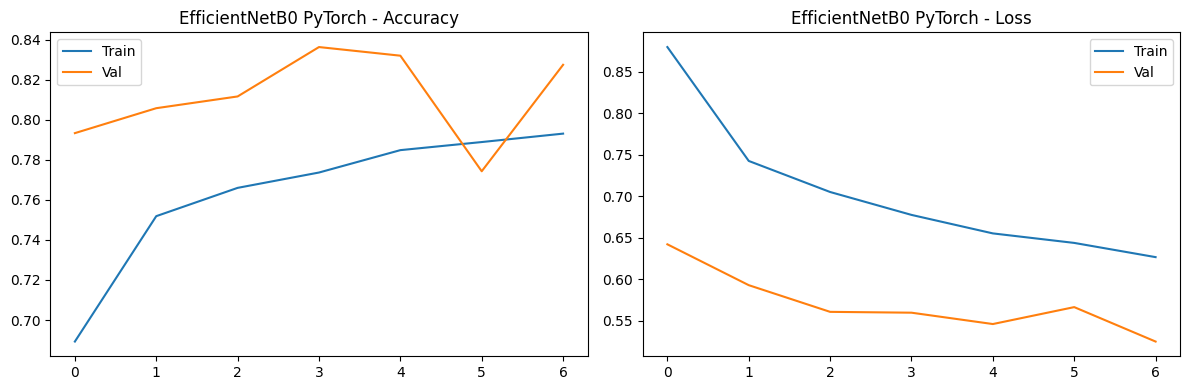

EfficientNetB0 PyTorch Test Accuracy: 0.8500
              precision    recall  f1-score   support

         CNV       0.97      0.86      0.91      3963
         DME       0.85      0.77      0.81      1377
      DRUSEN       0.57      0.68      0.62      1103
      NORMAL       0.83      0.94      0.88      2874

    accuracy                           0.85      9317
   macro avg       0.81      0.81      0.81      9317
weighted avg       0.86      0.85      0.85      9317



In [13]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

eff_torch = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all
for param in eff_torch.parameters(): param.requires_grad = False

# Son classifier katmanını değiştir
in_features = eff_torch.classifier[1].in_features
eff_torch.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)
eff_torch = eff_torch.to(DEVICE)

print('Aşama 1: Frozen (8 epoch)...')
train_torch(eff_torch, train_loader_128, val_loader_128, epochs=8,
            class_weights=class_weights_tensor, save_path='best_eff_torch.pth')

print('\nAşama 2: Fine-tuning (7 epoch)...')
# Son features bloğunu aç
for param in eff_torch.features[-3:].parameters(): param.requires_grad = True
history_eff_torch = train_torch(eff_torch, train_loader_128, val_loader_128, epochs=7,
                                 class_weights=class_weights_tensor, save_path='best_eff_torch.pth')

plot_torch_history(history_eff_torch, 'EfficientNetB0 PyTorch')
y_true_eff_torch, y_pred_eff_torch = eval_torch(eff_torch, test_loader_128,
                                                  'best_eff_torch.pth', 'EfficientNetB0 PyTorch')


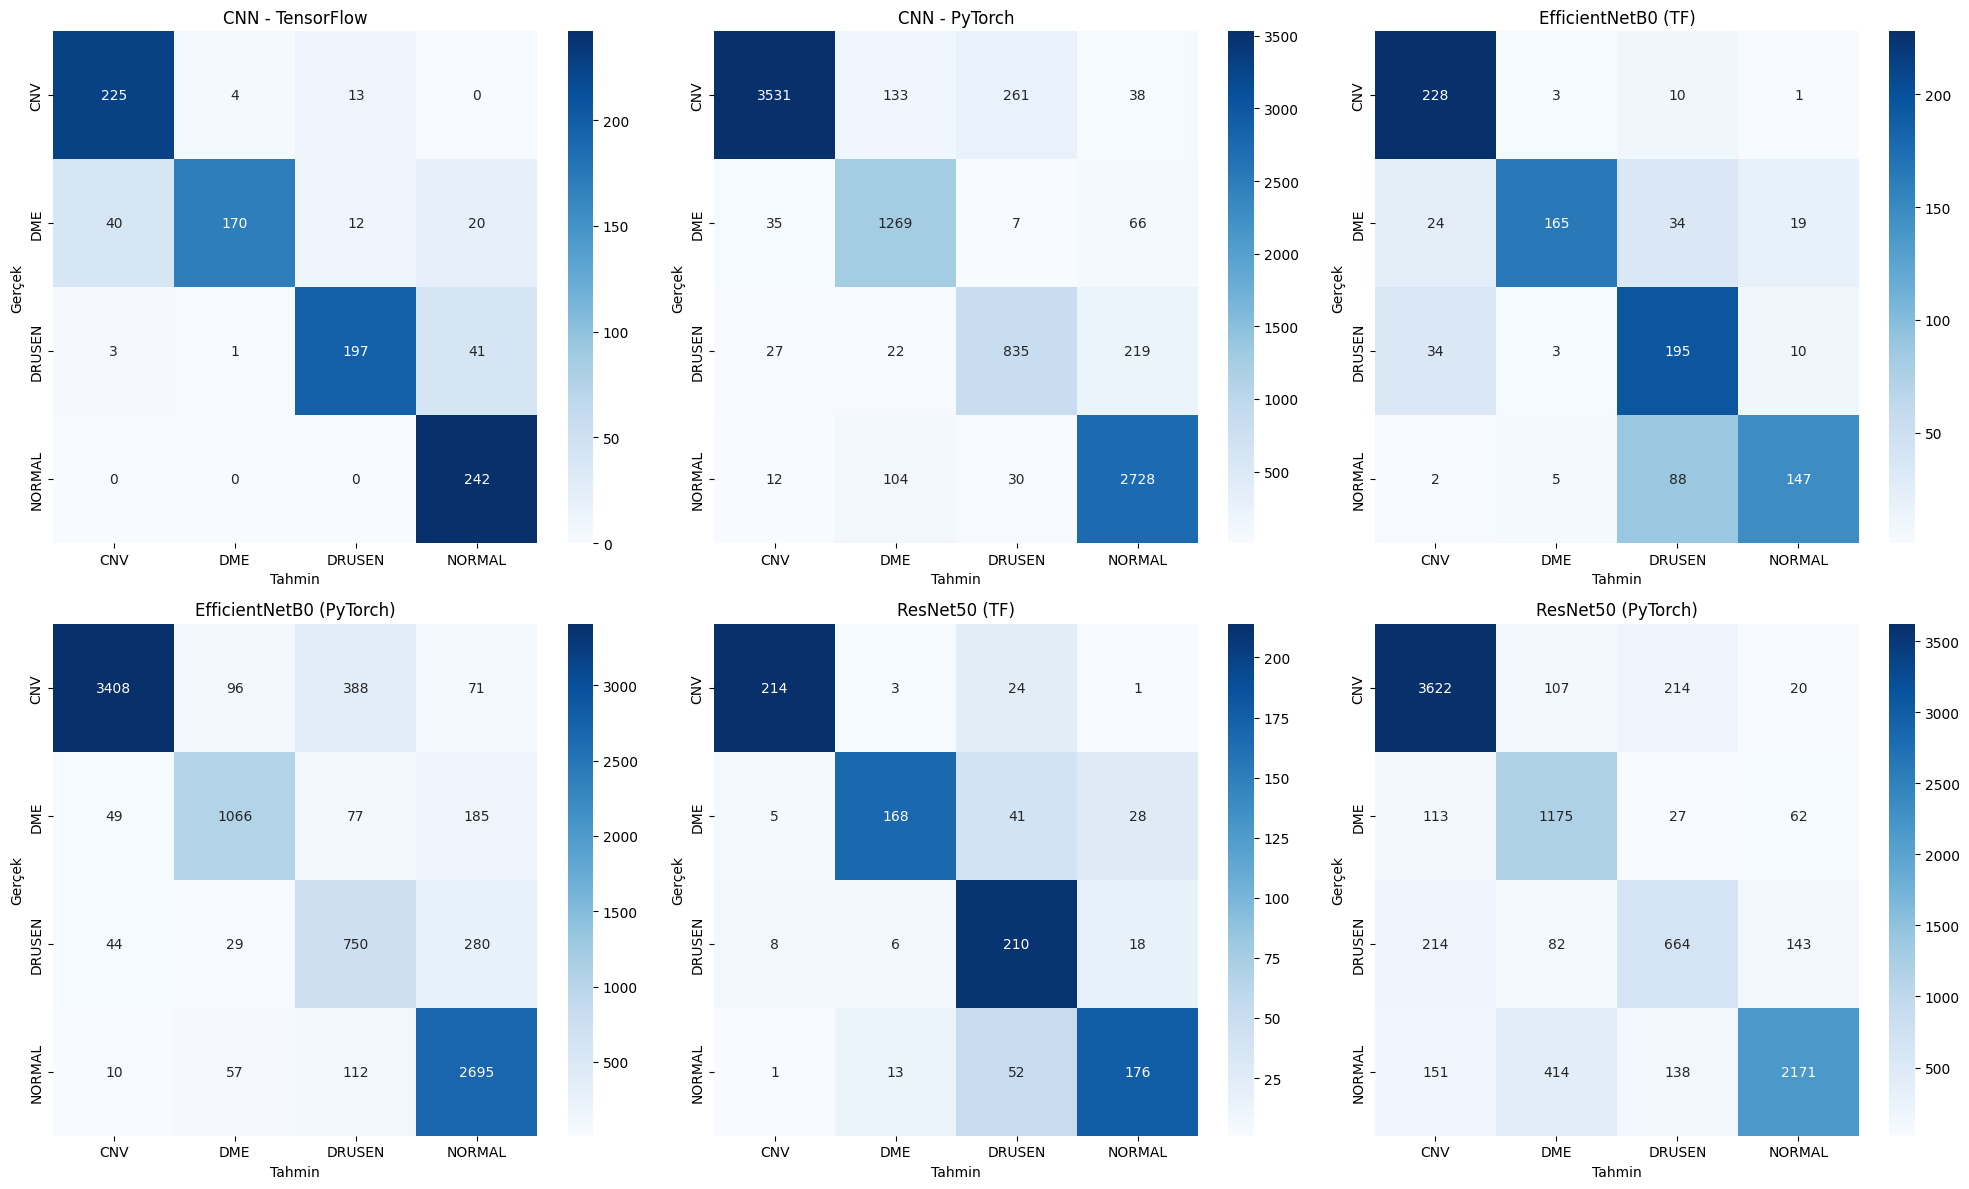

                   Model  Accuracy  F1-Score (weighted)
           CNN - PyTorch  0.897607             0.898505
        CNN - TensorFlow  0.861570             0.858728
EfficientNetB0 (PyTorch)  0.849952             0.853360
      ResNet50 (PyTorch)  0.819148             0.819641
           ResNet50 (TF)  0.793388             0.795886
     EfficientNetB0 (TF)  0.759298             0.759234


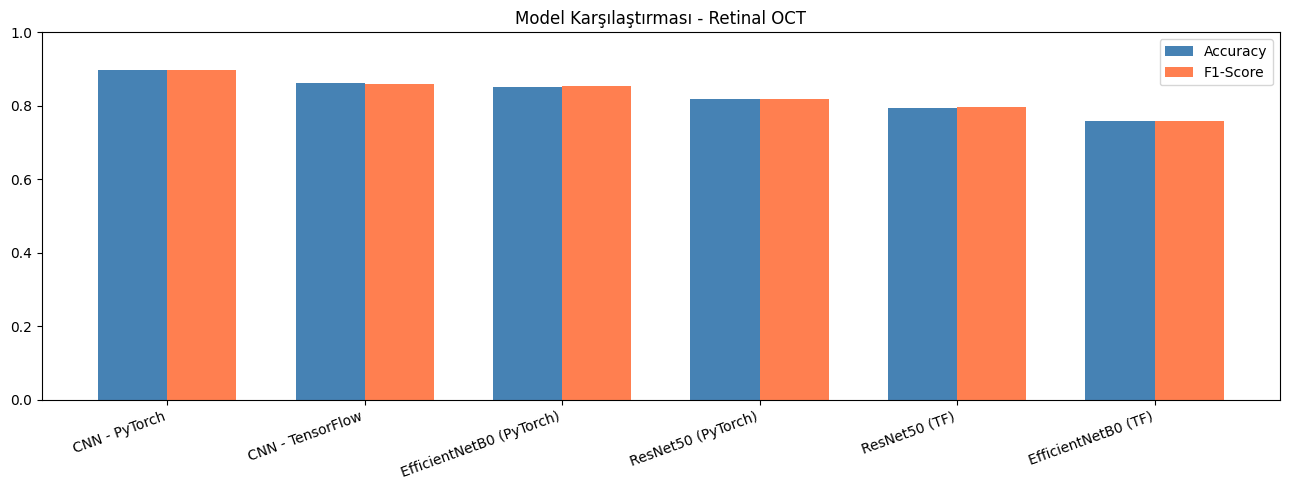

In [14]:
from sklearn.metrics import accuracy_score, f1_score

# Confusion Matrix - 6 model
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

all_results = [
    ('CNN - TensorFlow',        y_true_cnn_tf,       y_pred_cnn_tf),
    ('CNN - PyTorch',           y_true_cnn_torch,    y_pred_cnn_torch),
    ('EfficientNetB0 (TF)',     y_true_eff,          y_pred_eff),
    ('EfficientNetB0 (PyTorch)',y_true_eff_torch,    y_pred_eff_torch),
    ('ResNet50 (TF)',           y_true_resnet_tf,    y_pred_resnet_tf),
    ('ResNet50 (PyTorch)',      y_true_resnet,       y_pred_resnet),
]

for ax, (name, y_true, y_pred) in zip(axes.flatten(), all_results):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')

plt.tight_layout()
plt.show()

# Özet tablo
results_df = pd.DataFrame({
    'Model': [r[0] for r in all_results],
    'Accuracy': [accuracy_score(r[1], r[2]) for r in all_results],
    'F1-Score (weighted)': [f1_score(r[1], r[2], average='weighted') for r in all_results]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_df))
w = 0.35
ax.bar(x - w/2, results_df['Accuracy'],            w, label='Accuracy',  color='steelblue')
ax.bar(x + w/2, results_df['F1-Score (weighted)'], w, label='F1-Score',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Model Karşılaştırması - Retinal OCT')
ax.legend()
plt.tight_layout()
plt.show()
